# C2 · Bifurcation Analysis of the Enzyme Oscillator

**Module C — Oscillations & Signalling**

In C1 we fixed all parameters and watched the system oscillate. Here we ask a more fundamental question:

> *For what values of the substrate inflow rate a₁ does the system oscillate at all?*

The answer is encoded in a **bifurcation diagram** — the central tool for understanding how qualitative behaviour changes with a parameter. By the end of this notebook you will be able to:

1. Explain what a bifurcation diagram shows and how it is computed.  
2. Identify the oscillatory window in parameter space for the enzyme oscillator.  
3. Interactively shift that window by tuning the inhibition strength *k*ᵢ.

## 1 · What Is a Bifurcation Diagram?

A time series tells you what the system does at one parameter value. A bifurcation diagram tells you what it does across a whole *range* of values.

**How it is built (the min–max method):**

1. Fix a parameter value (here *a*₁).  
2. Simulate long enough that transients die away — this is the *warm-up* phase.  
3. Record the **minimum** and **maximum** of the variable in the remaining *analysis* window.  
4. Plot those two numbers as dots above that parameter value.  
5. Repeat across the parameter range.

**Reading the diagram:**

| Pattern | Meaning |
|---|---|
| min ≈ max (dots overlap) | Steady state — the system settles to a fixed point |
| min ≠ max (dots separate) | Oscillation — the variable cycles between the two extremes |
| Abrupt jump | Bifurcation point — qualitative change in behaviour |

The parameter values where the dots *first* split apart or *last* merge back together are called **Hopf bifurcation points**: the system gains or loses a limit cycle at those exact values.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import ipywidgets as widgets
from IPython.display import display

# ── Model: substrate (S) → product (P) with feedback inhibition ──────────────
# P inhibits its own production (negative feedback via the enzyme).
# This is the same system as C1; here we treat a1 as a bifurcation parameter.

def model(t, y, a1, b1, a2, b2, k_max, K_m, k_i, n, m, q):
    S, P = y
    v = (k_max * S**n) / (K_m + S**m) / (1 + k_i * P**q)
    dS = a1 - b1 * S - v
    dP = a2 - b2 * P + v
    return [dS, dP]

# Default parameters (keep identical to C1 for continuity)
PARAMS = dict(b1=0.18, b2=0.05, a2=0.02,
              k_max=25.0, K_m=0.34, k_i=0.06,
              n=1, m=3, q=2.8)

print("Model loaded. Parameters:")
for k, v in PARAMS.items():
    print(f"  {k} = {v}")

Model loaded. Parameters:
  b1 = 0.18
  b2 = 0.05
  a2 = 0.02
  k_max = 25.0
  K_m = 0.34
  k_i = 0.06
  n = 1
  m = 3
  q = 2.8


## 2 · Computing the Diagram

### Continuation strategy

A naive scan would restart each simulation from the same initial condition. That can cause it to "miss" the oscillatory branch if the starting point is far from the attractor. Instead we use **continuation**: the endpoint of one simulation becomes the starting point for the next. This keeps the trajectory on the attractor as *a*₁ changes slowly, giving a smoother, more reliable diagram.

In [2]:
def asymptotic_extrema(a1, params, ic, t_transient=500, t_analysis=200):
    """Simulate, discard warm-up, return (S_min, S_max, P_min, P_max)."""
    t_end = t_transient + t_analysis
    args  = (a1, params['b1'], params['a2'], params['b2'],
             params['k_max'], params['K_m'], params['k_i'],
             params['n'], params['m'], params['q'])
    sol = solve_ivp(model, [0, t_end], ic, args=args,
                   method='LSODA', dense_output=True,
                   rtol=1e-8, atol=1e-10)
    t_eval = np.linspace(t_transient, t_end, 2000)
    s = sol.sol(t_eval)
    return s[0].min(), s[0].max(), s[1].min(), s[1].max()


def bifurcation_scan(a1_range, params, ic, n_points=30,
                     t_transient=500, t_analysis=200):
    """Scan a1 and collect asymptotic extrema via continuation."""
    a1_vals = np.linspace(a1_range[0], a1_range[1], n_points)
    S_min, S_max, P_min, P_max = [], [], [], []
    cur_ic = list(ic)

    for i, a1 in enumerate(a1_vals):
        if (i + 1) % max(1, n_points // 10) == 0:
            print(f"  {i+1:3d}/{n_points}  a1 = {a1:.4f}", flush=True)
        try:
            sm, sM, pm, pM = asymptotic_extrema(a1, params, cur_ic,
                                                 t_transient, t_analysis)
            S_min.append(sm); S_max.append(sM)
            P_min.append(pm); P_max.append(pM)
            cur_ic = [(sm + sM) / 2, (pm + pM) / 2]   # continuation
        except Exception as e:
            print(f"  Warning at a1={a1:.4f}: {e}")
            last = [S_min[-1] if S_min else np.nan,
                    S_max[-1] if S_max else np.nan,
                    P_min[-1] if P_min else np.nan,
                    P_max[-1] if P_max else np.nan]
            S_min.append(last[0]); S_max.append(last[1])
            P_min.append(last[2]); P_max.append(last[3])

    return (a1_vals,
            np.array(S_min), np.array(S_max),
            np.array(P_min), np.array(P_max))


def plot_bifurcation(a1_vals, S_min, S_max, P_min, P_max, title_suffix=''):
    """Two-panel bifurcation diagram (S and P)."""
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 8), sharex=True)
    osc = '#4C9BE8'

    for ax, ymin, ymax, label in [
            (ax1, S_min, S_max, 'Substrate S'),
            (ax2, P_min, P_max, 'Product P')]:
        ax.fill_between(a1_vals, ymin, ymax, alpha=0.20, color=osc)
        ax.plot(a1_vals, ymin, 'o', color='steelblue',  ms=4, alpha=0.7,
                label='min', markeredgewidth=0)
        ax.plot(a1_vals, ymax, 'o', color='firebrick',  ms=4, alpha=0.7,
                label='max', markeredgewidth=0)
        ax.set_ylabel(label, fontsize=12)
        ax.grid(True, alpha=0.3, ls='--')
        ax.legend(fontsize=10)

    ax2.set_xlabel('Inflow rate  a₁', fontsize=12)
    ax1.set_title(f'Bifurcation diagram — enzyme oscillator{title_suffix}',
                  fontsize=13)
    plt.tight_layout()
    return fig


print("Helper functions defined.")

Helper functions defined.


## 3 · Fast Preview  (≈ 1–2 min)

Run this cell first to get a quick impression of the bifurcation structure using only 30 parameter values. The shape will already be clear; the high-resolution scan in the next section fills in the detail.

Fast preview — 30 points …
    3/30  a1 = 0.6362
    6/30  a1 = 0.6455
    9/30  a1 = 0.6548
   12/30  a1 = 0.6641
   15/30  a1 = 0.6734
   18/30  a1 = 0.6828
   21/30  a1 = 0.6921
   24/30  a1 = 0.7014
   27/30  a1 = 0.7107
   30/30  a1 = 0.7200
Done.


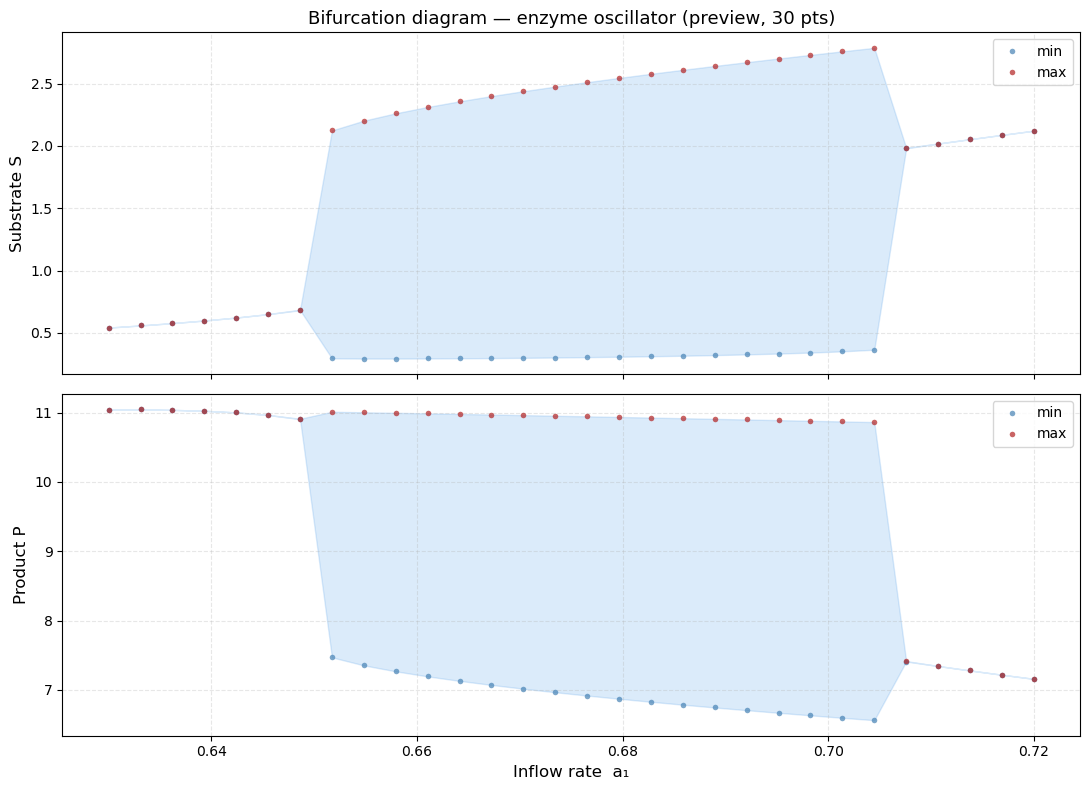

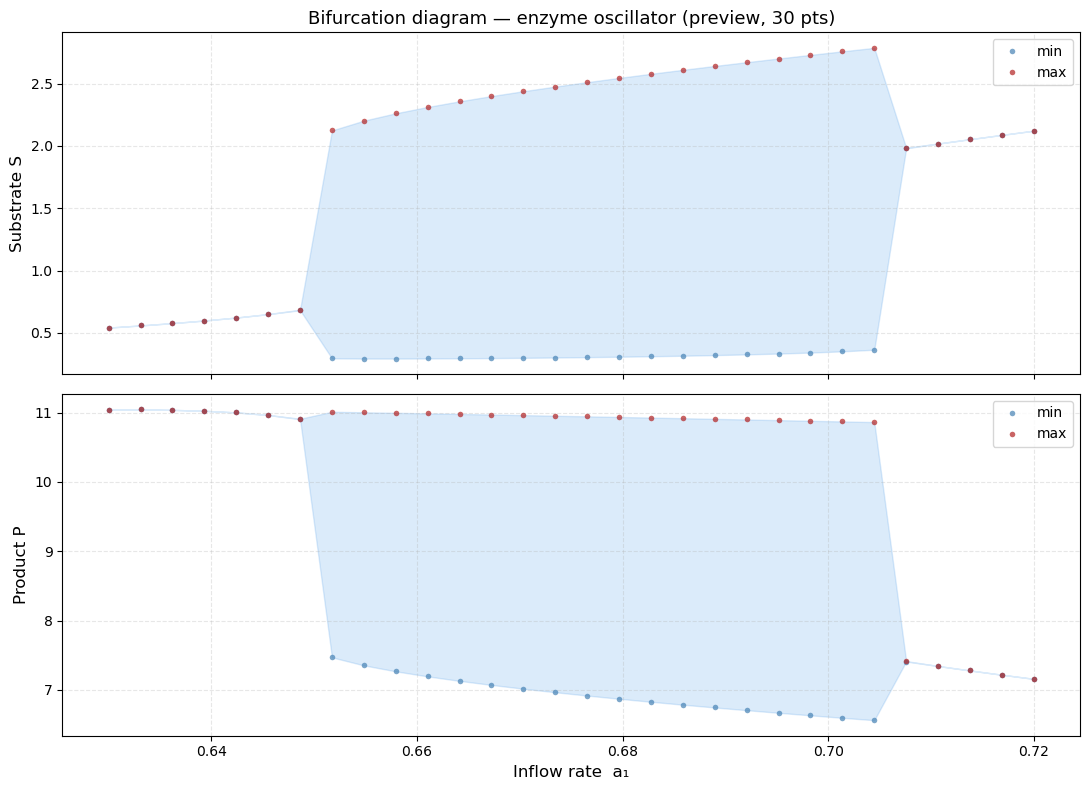

In [4]:
IC = [2.5, 0.6]   # initial conditions [S₀, P₀]

print("Fast preview — 30 points …")
a1v, Sm, SM, Pm, PM = bifurcation_scan(
    a1_range=[0.63, 0.72],
    params=PARAMS,
    ic=IC,
    n_points=30,
    t_transient=500,
    t_analysis=200,
)
print("Done.")
plot_bifurcation(a1v, Sm, SM, Pm, PM, title_suffix=' (preview, 30 pts)')

### Reading your preview

Look at the **substrate panel** (top):

- For low *a*₁ the two dots overlap → **steady state**: substrate settles.  
- At some threshold the dots *split apart* → **oscillation onset**   (lower Hopf bifurcation point).  
- They rejoin again at a higher *a*₁ → **oscillation termination**   (upper Hopf bifurcation point).  
- Between the two Hopf points is the **oscillatory window**.

The product panel mirrors this: when S oscillates, so does P — the two variables are coupled through the enzymatic reaction.

## 4 · Full-Resolution Scan  (≈ 10–15 min — optional)

This cell runs 150 parameter values for a publication-quality diagram. Skip it during the workshop if time is short — the preview already shows the key structure.

Full scan — 150 points …
   10/100  a1 = 0.6382
   20/100  a1 = 0.6473
   30/100  a1 = 0.6564
   40/100  a1 = 0.6655
   50/100  a1 = 0.6745
   60/100  a1 = 0.6836
   70/100  a1 = 0.6927
   80/100  a1 = 0.7018
   90/100  a1 = 0.7109
  100/100  a1 = 0.7200
Done.


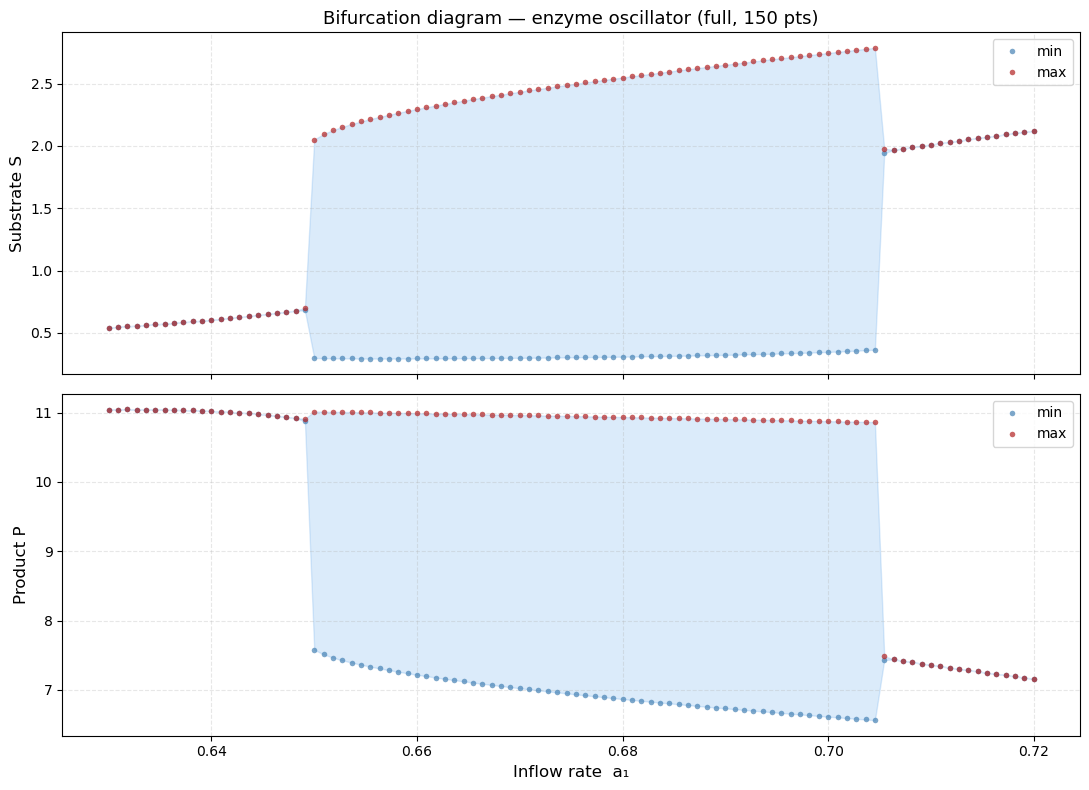

Figure saved.


In [5]:
# ⏱ This cell takes ~10–15 minutes. Run it when you have time to spare.
print("Full scan — 150 points …")
a1v_full, Sm_f, SM_f, Pm_f, PM_f = bifurcation_scan(
    a1_range=[0.63, 0.72],
    params=PARAMS,
    ic=IC,
    n_points=100,
    t_transient=500,
    t_analysis=200,
)
print("Done.")
fig_full = plot_bifurcation(a1v_full, Sm_f, SM_f, Pm_f, PM_f,
                            title_suffix=' (full, 150 pts)')
plt.show()
fig_full.savefig('bifurcation_diagram_oscillations.png',
                 dpi=150, bbox_inches='tight')
print("Figure saved.")

## 5 · Locating the Hopf Bifurcation Points

The oscillatory window is where the amplitude (max − min) exceeds a small threshold. The edges of that window are the Hopf points.

In [7]:
def analyse_oscillations(a1_vals, S_min, S_max, P_min, P_max, thr=0.01):
    """Print the oscillatory range and maximum amplitude."""
    for name, ymin, ymax in [('Substrate S', S_min, S_max),
                              ('Product P',   P_min, P_max)]:
        amp  = ymax - ymin
        mask = amp > thr
        if mask.any():
            a_start = a1_vals[mask][0]
            a_end   = a1_vals[mask][-1]
            i_peak  = np.argmax(amp)
            print(f"{name}:")
            print(f"  Oscillatory window : a₁ ∈ [{a_start:.4f}, {a_end:.4f}]")
            print(f"  Peak amplitude     : {amp[i_peak]:.4f}  "
                  f"at a₁ = {a1_vals[i_peak]:.4f}")
        else:
            print(f"{name}: no oscillations detected")
        print()

# Run on the preview result (replace a1v/Sm/SM/Pm/PM with the full-scan
# variables if you ran Cell 4 above)
analyse_oscillations(a1v, Sm, SM, Pm, PM)

Substrate S:
  Oscillatory window : a₁ ∈ [0.6517, 0.7045]
  Peak amplitude     : 2.4209  at a₁ = 0.7045

Product P:
  Oscillatory window : a₁ ∈ [0.6517, 0.7045]
  Peak amplitude     : 4.2998  at a₁ = 0.7045



## 6 · The Hopf Bifurcation — What It Means Biologically

A **Hopf bifurcation** is the birth (or death) of a limit cycle as a parameter crosses a critical value. For this enzyme oscillator:

- Below the lower Hopf point (*a*₁ too small): not enough substrate enters   to sustain cycling. The system drains to a steady state.  
- Inside the oscillatory window: the inflow keeps the substrate replenished   fast enough for the feedback inhibition loop to drive sustained oscillations.  
- Above the upper Hopf point (*a*₁ too large): the system is flooded;   inhibition is overwhelmed and again settles to a (high) steady state.

This "window of opportunity" is a recurring theme in biological oscillators — the same logic governs calcium spikes, cAMP waves in *Dictyostelium*, and the circadian clock.

## 7 · Interactive Exploration — How Does Inhibition Strength Shift the Window?

The width and position of the oscillatory window depends on model parameters. Use the widget below to vary the **inhibition constant *k*ᵢ** and re-run a fast 30-point scan. Increasing *k*ᵢ makes the product a stronger inhibitor — watch how that changes the system's propensity to oscillate.

In [8]:
# ── Widgets ──────────────────────────────────────────────────────────────────
sl_ki   = widgets.FloatSlider(value=0.06, min=0.01, max=0.20, step=0.01,
                               description='k_i', continuous_update=False,
                               style={'description_width': 'initial'})
sl_a1lo = widgets.FloatSlider(value=0.60, min=0.40, max=0.80, step=0.01,
                               description='a₁ min', continuous_update=False,
                               style={'description_width': 'initial'})
sl_a1hi = widgets.FloatSlider(value=0.75, min=0.50, max=1.00, step=0.01,
                               description='a₁ max', continuous_update=False,
                               style={'description_width': 'initial'})
btn     = widgets.Button(description='▶  Run scan',
                         button_style='success', layout=widgets.Layout(width='150px'))
out     = widgets.Output()

def on_run(b):
    out.clear_output(wait=True)
    p = dict(PARAMS)          # copy defaults
    p['k_i'] = sl_ki.value
    a1_lo = sl_a1lo.value
    a1_hi = sl_a1hi.value
    if a1_lo >= a1_hi:
        with out:
            print("a₁ min must be less than a₁ max.")
        return
    with out:
        print(f"Scanning a₁ ∈ [{a1_lo:.2f}, {a1_hi:.2f}]  "
              f"with k_i = {sl_ki.value:.2f} …")
        a1v_w, Sm_w, SM_w, Pm_w, PM_w = bifurcation_scan(
            a1_range=[a1_lo, a1_hi],
            params=p, ic=IC,
            n_points=30, t_transient=500, t_analysis=200,
        )
        plot_bifurcation(a1v_w, Sm_w, SM_w, Pm_w, PM_w,
                         title_suffix=f'  (k_i = {sl_ki.value:.2f})')
        plt.show()
        analyse_oscillations(a1v_w, Sm_w, SM_w, Pm_w, PM_w)

btn.on_click(on_run)

display(widgets.VBox([
    widgets.HBox([sl_ki]),
    widgets.HBox([sl_a1lo, sl_a1hi]),
    btn,
    out
]))